## 03.02 Detecting Concept Drift

In [1]:
#Install s/w required for the exercise
!pip install pandas
!pip install scikit-learn
!pip install alibi-detect

In [2]:
#Build a model to use for concept drift detection
import pandas as pd
from sklearn.model_selection import train_test_split

#Load the dataset
credit_train_df = pd.read_csv("credit-approval-training-data.csv")
print(credit_train_df)

     APPLICANT_ID  AGE_RANGE  INCOME_CATEGORY  RACE  CREDIT_RATING  APPROVED
0               1          3                4     2              6         0
1               2          3                4     3              5         0
2               3          2                3     4              6         0
3               4          2                2     5              6         0
4               5          1                4     4              5         0
..            ...        ...              ...   ...            ...       ...
995           996          2                4     5              5         1
996           997          1                1     2              1         1
997           998          3                2     4              5         0
998           999          1                4     3              4         0
999          1000          3                1     4              6         0

[1000 rows x 6 columns]


In [3]:
#Split into training and test sets
trng_features = credit_train_df[["AGE_RANGE",
                                 "INCOME_CATEGORY",
                                 "RACE",
                                 "CREDIT_RATING"]]
trng_target=credit_train_df[["APPROVED"]]

train_X, test_X, train_Y, test_Y = (train_test_split(
    trng_features,trng_target,test_size = 0.30))

print(train_X.shape,test_X.shape)

(700, 4) (300, 4)


In [4]:
#Build a Naive Bayes model to predict load approval
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

credit_classifier = GaussianNB()
credit_model = credit_classifier.fit(train_X,train_Y.values.ravel())

approval_predictions = credit_classifier.predict(test_X)
print("Training Classifier Accuracy : ", 
      accuracy_score(test_Y,approval_predictions))



Training Classifier Accuracy :  0.9266666666666666


In [9]:
#Analyze Production data for performance
credit_prod_df = pd.read_csv("credit-approval-prod-data.csv")

prod_features = credit_prod_df[["AGE_RANGE",
                                "INCOME_CATEGORY",
                                "RACE",
                                "CREDIT_RATING"]]
prod_target=credit_prod_df[["APPROVED"]]

prod_predictions = credit_classifier.predict(prod_features)
print("Production Classifier Accuracy : ", 
      accuracy_score(prod_target,prod_predictions))


Production Classifier Accuracy :  0.375


In [6]:
#Analyze correlation between training and production features vs target
correlation=credit_train_df.corr()["APPROVED"][["AGE_RANGE",
                                                "INCOME_CATEGORY",
                                                "RACE",
                                                "CREDIT_RATING"]].to_frame()
correlation=correlation.rename(columns={"APPROVED":"TRAINING"})

corr_prod=credit_prod_df.corr()["APPROVED"][["AGE_RANGE",
                                             "INCOME_CATEGORY",
                                             "RACE",
                                             "CREDIT_RATING"]]
correlation["PRODUCTION"]= corr_prod
correlation["CHANGE_PERCENT"] = (correlation["TRAINING"] 
                                 - correlation["PRODUCTION"]) \
                                        / correlation["TRAINING"] * 100

print(" Correlation\n",correlation)

 Correlation
                  TRAINING  PRODUCTION  CHANGE_PERCENT
AGE_RANGE       -0.036363   -0.027058       25.589600
INCOME_CATEGORY -0.011627   -0.011459        1.442199
RACE             0.481963    0.463592        3.811681
CREDIT_RATING   -0.675915    0.525804      177.791342


## 03.04. Detecting Feature Drift

array([[<Axes: title={'center': 'AGE_RANGE'}>,
        <Axes: title={'center': 'INCOME_CATEGORY'}>,
        <Axes: title={'center': 'RACE'}>,
        <Axes: title={'center': 'CREDIT_RATING'}>]], dtype=object)

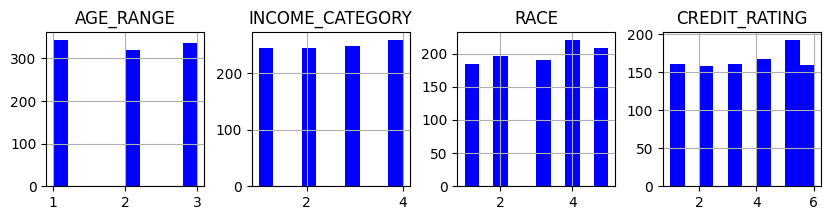

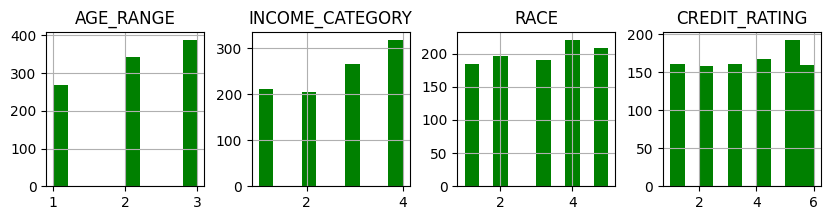

In [7]:
# Data Distribution analyzis between training and production

trng_features.hist(color="blue",figsize=(10,2),layout=(1,4))

prod_features.hist(color="green", figsize=(10,2),layout=(1,4))


In [10]:
from alibi_detect.cd import ChiSquareDrift

#Initialize the drift detector
drift_detector = ChiSquareDrift(trng_features.to_numpy(), p_val=0.05)
drift_prediction = drift_detector.predict(prod_features.to_numpy())

features = trng_features.keys()

for f in range(len(features)):
    fname = features[f]
    is_drift = (drift_prediction['data']['p_val'][f] < drift_prediction['data']['threshold']).astype(int)
    p_val = drift_prediction['data']['p_val'][f]
    print(f'{fname} -- Drift? {is_drift} -- p-value {p_val:.3f}')

AGE_RANGE -- Drift? 1 -- p-value 0.001
INCOME_CATEGORY -- Drift? 1 -- p-value 0.005
RACE -- Drift? 0 -- p-value 1.000
CREDIT_RATING -- Drift? 0 -- p-value 1.000
